In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls "/content/drive/My Drive"

'Colab Notebooks'   L3	'Выборка для ДЗ№4.zip'


In [3]:
!ls "/content/drive/My Drive/L3"

bending  lying	sitting  standing


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [5]:
dataset_dir = "/content/drive/My Drive/L3"

img_height = 64
img_width = 64
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 4800 files belonging to 4 classes.
Using 3840 files for training.
Found 4800 files belonging to 4 classes.
Using 960 files for validation.
['bending', 'lying', 'sitting', 'standing']


In [6]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [7]:
model_without_dropout = keras.Sequential([
    keras.Input(shape=(img_height, img_width, 3)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(4, activation='softmax')
])

model_without_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model_without_dropout.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,396 (12.16 MB)

 Trainable params: 3,187,396 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
history_without_dropout = model_without_dropout.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20
)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.5807 - loss: 1.4611 - val_accuracy: 0.6979 - val_loss: 0.8010
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 234ms/step - accuracy: 0.6966 - loss: 0.8461 - val_accuracy: 0.7365 - val_loss: 0.6904
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 234ms/step - accuracy: 0.7263 - loss: 0.7570 - val_accuracy: 0.7594 - val_loss: 0.6225
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.7346 - loss: 0.7056 - val_accuracy: 0.7354 - val_loss: 0.7037
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 227ms/step - accuracy: 0.7708 - loss: 0.6076 - val_accuracy: 0.7990 - val_loss: 0.5574
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 29s 238ms/step - accuracy: 0.7930 - loss: 0.5653 - val_accuracy: 0.8406 - val_loss: 0.4610
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 236ms/step - accuracy: 0.8206 - loss: 0.5017 - val_accuracy: 0.8281 - val_loss: 0.5025
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 234ms/step - accuracy: 0.8393 - loss: 0.4

In [9]:
model_with_dropout = keras.Sequential([
    keras.Input(shape=(img_height, img_width, 3)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(4, activation='softmax')
])

model_with_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model_with_dropout.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,396 (12.16 MB)

 Trainable params: 3,187,396 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
history_with_dropout = model_with_dropout.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20
)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.4214 - loss: 1.9476 - val_accuracy: 0.6521 - val_loss: 0.9982
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 234ms/step - accuracy: 0.5617 - loss: 1.0342 - val_accuracy: 0.6781 - val_loss: 0.8143
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 230ms/step - accuracy: 0.5982 - loss: 0.9614 - val_accuracy: 0.7229 - val_loss: 0.8134
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 227ms/step - accuracy: 0.5880 - loss: 0.9674 - val_accuracy: 0.6969 - val_loss: 0.8104
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - accuracy: 0.6094 - loss: 0.9246 - val_accuracy: 0.7333 - val_loss: 0.7673
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 237ms/step - accuracy: 0.5482 - loss: 0.9673 - val_accuracy: 0.6396 - val_loss: 0.8391
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 236ms/step - accuracy: 0.5388 - loss: 0.9929 - val_accuracy: 0.6354 - val_loss: 0.8105
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 229ms/step - accuracy: 0.5544 - loss: 0

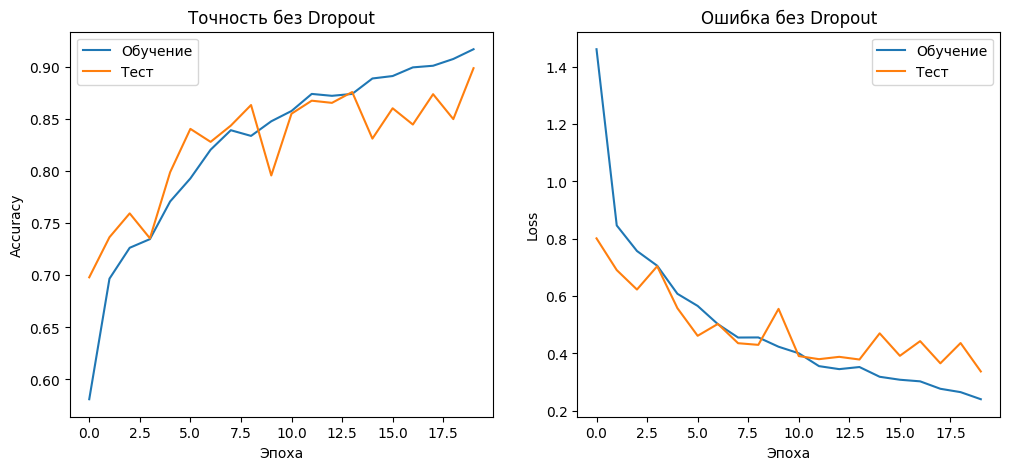

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_without_dropout.history['accuracy'], label='Обучение')
plt.plot(history_without_dropout.history['val_accuracy'], label='Тест')
plt.title('Точность без Dropout')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_without_dropout.history['loss'], label='Обучение')
plt.plot(history_without_dropout.history['val_loss'], label='Тест')
plt.title('Ошибка без Dropout')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.show()

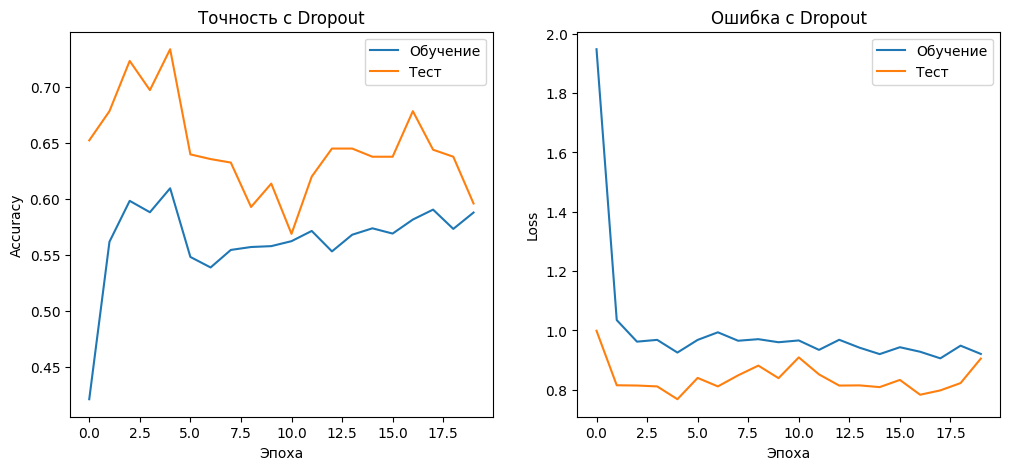

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_with_dropout.history['accuracy'], label='Обучение')
plt.plot(history_with_dropout.history['val_accuracy'], label='Тест')
plt.title('Точность с Dropout')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_with_dropout.history['loss'], label='Обучение')
plt.plot(history_with_dropout.history['val_loss'], label='Тест')
plt.title('Ошибка с Dropout')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [13]:
test_loss_no, test_accuracy_no = model_without_dropout.evaluate(test_ds)
test_loss_drop, test_accuracy_drop = model_with_dropout.evaluate(test_ds)

print("Без Dropout:")
print("Точность на тестовой выборке:", test_accuracy_no)
print("Ошибка на тестовой выборке:", test_loss_no)

print()

print("С Dropout:")
print("Точность на тестовой выборке:", test_accuracy_drop)
print("Ошибка на тестовой выборке:", test_loss_drop)

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.8990 - loss: 0.3366
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.5958 - loss: 0.9043
Без Dropout:
Точность на тестовой выборке: 0.8989583253860474
Ошибка на тестовой выборке: 0.33658674359321594

С Dropout:
Точность на тестовой выборке: 0.5958333611488342
Ошибка на тестовой выборке: 0.9042996764183044


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


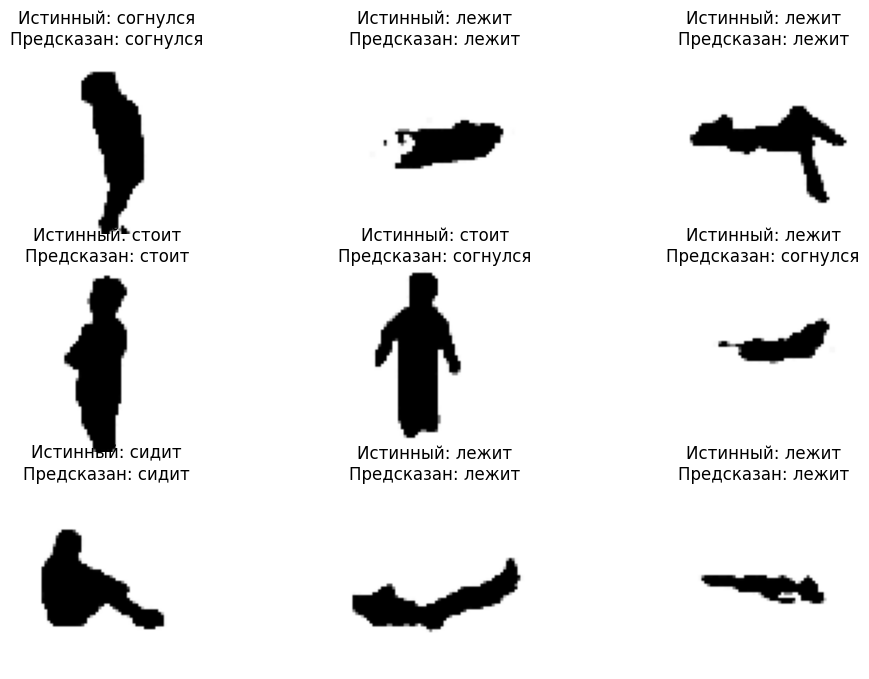

In [14]:
class_labels = {
    "bending": "согнулся",
    "lying": "лежит",
    "sitting": "сидит",
    "standing": "стоит"
}

for images, labels in test_ds.take(1):
    predictions = model_with_dropout.predict(images)

    plt.figure(figsize=(12, 8))

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        predicted_index = np.argmax(predictions[i])
        true_index = labels[i].numpy()

        predicted_class = class_names[predicted_index]
        true_class = class_names[true_index]

        plt.title(
            f"Истинный: {class_labels[true_class]}\n"
            f"Предсказан: {class_labels[predicted_class]}"
        )

        plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


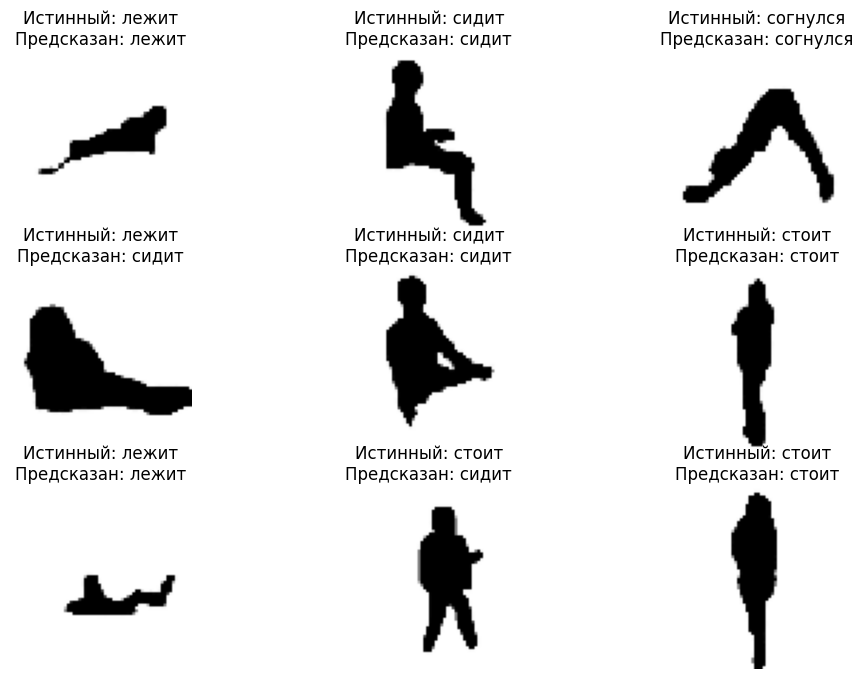

In [15]:
class_labels = {
    "bending": "согнулся",
    "lying": "лежит",
    "sitting": "сидит",
    "standing": "стоит"
}

for images, labels in test_ds.take(1):
    predictions = model_without_dropout.predict(images)

    plt.figure(figsize=(12, 8))

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        predicted_index = np.argmax(predictions[i])
        true_index = labels[i].numpy()

        predicted_class = class_names[predicted_index]
        true_class = class_names[true_index]

        plt.title(
            f"Истинный: {class_labels[true_class]}\n"
            f"Предсказан: {class_labels[predicted_class]}"
        )

        plt.axis("off")

    plt.show()